<a href="https://colab.research.google.com/github/AnuGuin/os-lab/blob/main/SPP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# **Data-Loading, Pre-processing and visualization**

In [ ]:
df = pd.read_csv('/content/all_stocks_5yr.csv')
df = df[0:1259]
df = df.drop(columns=['Name'])
df.head()


,date,open,high,low,close,volume
0,2013-02-08,15.07,15.12,14.63,14.75,8407500.0
1,2013-02-11,14.89,15.01,14.26,14.46,8882000.0
2,2013-02-12,14.45,14.51,14.10,14.27,8126000.0
3,2013-02-13,14.30,14.94,14.25,14.66,10259500.0
4,2013-02-14,14.94,14.96,13.16,13.99,31879900.0


In [ ]:
data = df[['date', 'close']]
data.head()

,date,close
0,2013-02-08,14.75
1,2013-02-11,14.46
2,2013-02-12,14.27
3,2013-02-13,14.66
4,2013-02-14,13.99


In [ ]:
# Convert 'date' column to datetime objects
data['date'] = pd.to_datetime(data['date'])

# Group by year and month, and calculate the average
monthly_avg = data.groupby([data['date'].dt.year,data['date'].dt.month]).mean()

# Print or use the resulting DataFrame
monthly_avg

<ipython-input-5-8370b313d0cd>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date'] = pd.to_datetime(data['date'])


date      close
date date                                         
2013 2    2013-02-18 15:25:42.857142784  13.877143
     3    2013-03-15 02:24:00.000000000  15.776500
     4    2013-04-14 22:54:32.727272704  16.108636
     5    2013-05-15 20:43:38.181818112  17.810909
     6    2013-06-15 12:00:00.000000000  16.839000
...                                 ...        ...
2017 10   2017-10-15 22:54:32.727272704  50.756364
     11   2017-11-15 08:00:00.000000000  47.587143
     12   2017-12-15 07:12:00.000000000  51.150500
2018 1    2018-01-16 09:08:34.285714176  54.902857
     2    2018-02-04 04:48:00.000000000  51.664000

[61 rows x 2 columns]

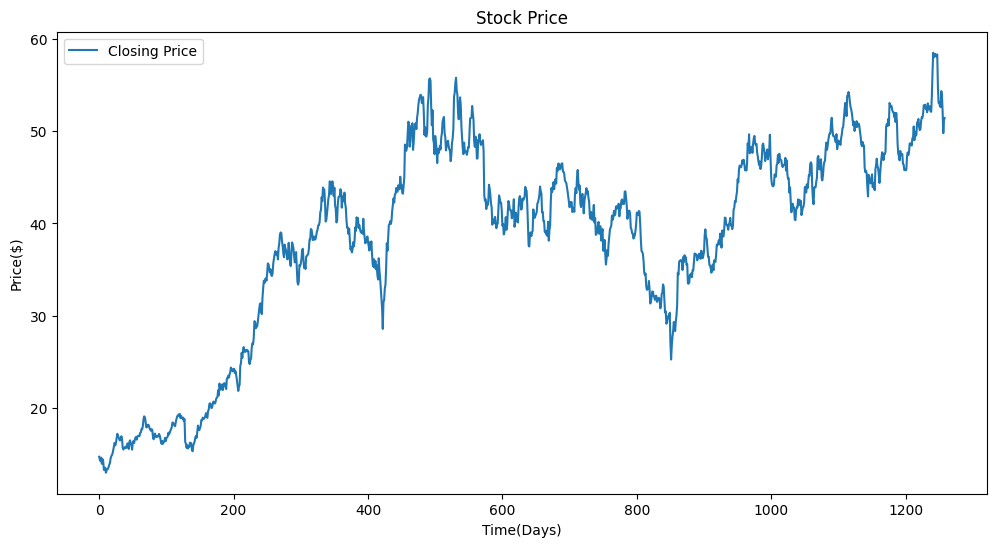

In [ ]:
# 1. Plot the stock price
plt.figure(figsize=(12, 6))
plt.plot(df['close'], label='Closing Price')
plt.title('Stock Price')
plt.xlabel('Time(Days)')
plt.ylabel('Price($)')
plt.legend()
plt.show()

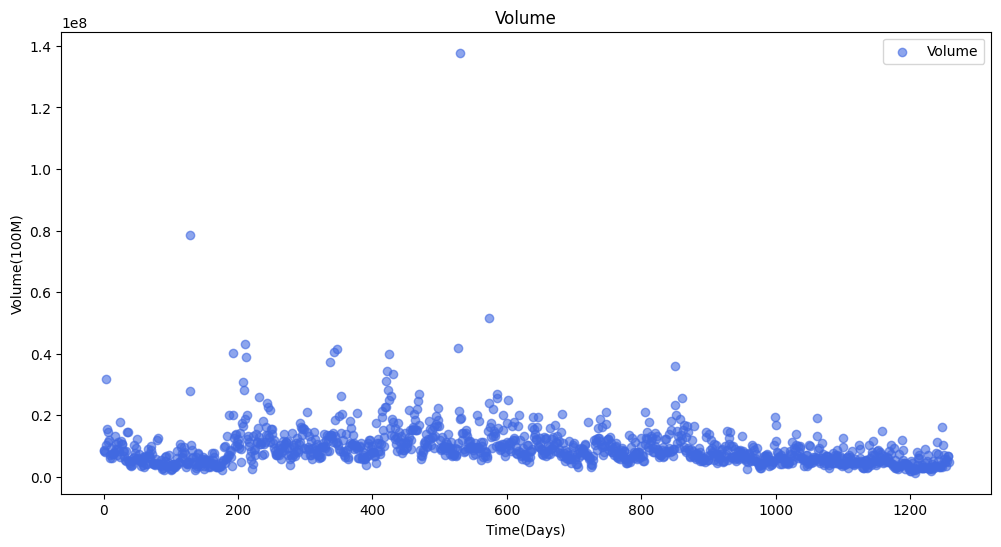

In [ ]:
scPlot = df['volume']
plt.figure(figsize=(12, 6))
plt.scatter(df.index,scPlot,color='royalblue', alpha=0.6,label='Volume')
plt.title('Volume')
plt.xlabel('Time(Days)')
plt.ylabel('Volume(100M)')
plt.legend()
plt.show()

In [ ]:
# monthly_avg.set_index('date', inplace=True)
data_main = monthly_avg['close'].values.reshape(-1, 1)

# Scale the data (LSTM works better with scaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_main)

In [ ]:
scaled_data.shape

(61, 1)

# **Data feeding, Model Training**

In [ ]:
def create_dataset(dataset, look_back=1):
    X, Y = [], []

    # Convert dataset to NumPy array if not already
    dataset = np.array(dataset, dtype=np.float32)

    # Ensure dataset is at least 2D
    if dataset.ndim == 1:
        dataset = dataset.reshape(-1, 1)

    # Ensure dataset has enough samples
    if len(dataset) < look_back + 1:
        print("Error: Dataset too small for the look_back period.")
        return np.array([]), np.array([])

    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]  # Extract 'look_back' time steps
        X.append(a)
        Y.append(dataset[i + look_back, 0])  # Predict next value

    # Convert to NumPy arrays
    X, Y = np.array(X), np.array(Y)

    # Ensure the shape is correct before returning
    if X.ndim == 1:
        X = X.reshape(-1, look_back)  # Convert (N,) to (N, look_back)

    return X, Y

# Example Usage
look_back = 24
X, Y = create_dataset(data_main, look_back)
print("X shape:", X.shape)  # Should be (N, look_back)
print("Y shape:", Y.shape)  # Should be (N,)


X shape: (37, 24)
Y shape: (37,)


In [ ]:

look_back = 24  # Using your previous lookback period
X, Y = create_dataset(scaled_data, look_back)

# 2. Split into train and test sets (e.g., 80% train, 20% test)
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

trainX, testX = X[0:train_size], X[train_size:len(X)]
trainY, testY = Y[0:train_size], Y[train_size:len(Y)]

# 3. Reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
trainY = np.reshape(trainY, (trainY.shape[0], 1))
testY = np.reshape(testY, (testY.shape[0], 1))
print(f"Training set shape: {trainX.shape}")
print(f"Testing set shape: {testX.shape}")
print(f"Training labels shape: {trainY.shape}")
print(f"Testing labels shape: {testY.shape}")

Training set shape: (29, 24, 1)
Testing set shape: (8, 24, 1)
Training labels shape: (29, 1)
Testing labels shape: (8, 1)


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [ ]:
# 4. Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

# 5. Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

# 6. Train the model
history = model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)  # Adjust epochs and batch size as needed

# 7. Make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

print(trainPredict)
# (You can then proceed with evaluating the model and visualizing the results)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 - 4s - 154ms/step - loss: 0.0672
Epoch 2/100
29/29 - 0s - 12ms/step - loss: 0.0272
Epoch 3/100
29/29 - 0s - 12ms/step - loss: 0.0241
Epoch 4/100
29/29 - 1s - 22ms/step - loss: 0.0218
Epoch 5/100
29/29 - 1s - 21ms/step - loss: 0.0228
Epoch 6/100
29/29 - 1s - 21ms/step - loss: 0.0176
Epoch 7/100
29/29 - 1s - 22ms/step - loss: 0.0174
Epoch 8/100
29/29 - 1s - 21ms/step - loss: 0.0169
Epoch 9/100
29/29 - 0s - 13ms/step - loss: 0.0204
Epoch 10/100
29/29 - 1s - 21ms/step - loss: 0.0186
Epoch 11/100
29/29 - 1s - 22ms/step - loss: 0.0154
Epoch 12/100
29/29 - 1s - 21ms/step - loss: 0.0132
Epoch 13/100
29/29 - 1s - 22ms/step - loss: 0.0113
Epoch 14/100
29/29 - 1s - 21ms/step - loss: 0.0121
Epoch 15/100
29/29 - 0s - 13ms/step - loss: 0.0123
Epoch 16/100
29/29 - 0s - 12ms/step - loss: 0.0125
Epoch 17/100
29/29 - 1s - 22ms/step - loss: 0.0126
Epoch 18/100
29/29 - 1s - 29ms/step - loss: 0.0111
Epoch 19/100
29/29 - 1s - 21ms/step - loss: 0.0101
Epoch 20/100
29/29 - 1s - 21ms/step - l

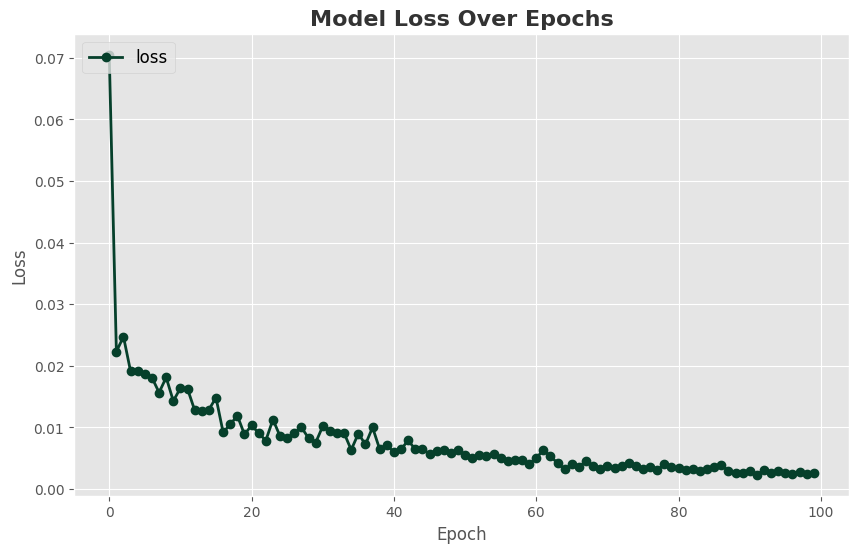

In [ ]:
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(history.history['loss'], label='loss', color="#06402B", linewidth=2, linestyle='-',marker='o')
plt.title('Model Loss Over Epochs', fontsize=16, fontweight='bold', color='#333333')
plt.xlabel('Epoch',fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.show()

In [ ]:
# Descale predictions
trainPredict = scaler.inverse_transform(trainPredict)
testPredict = scaler.inverse_transform(testPredict)

print("Descaled Train Predictions:\n", trainPredict)
print("Descaled Test Predictions:\n", testPredict)

Descaled Train Predictions:
 [[51.886364]
 [48.6393  ]
 [48.83477 ]
 [45.985886]
 [43.443474]
 [40.532223]
 [41.5767  ]
 [42.580444]
 [42.751133]
 [44.027122]
 [43.816933]
 [43.179398]
 [40.22603 ]
 [37.9511  ]
 [38.170403]
 [35.26232 ]
 [32.028572]
 [32.42786 ]
 [35.950165]
 [37.96363 ]
 [39.530567]
 [41.935997]
 [45.274055]
 [47.488316]
 [46.014145]
 [44.767345]
 [43.329693]
 [45.815617]
 [48.29756 ]]
Descaled Test Predictions:
 [[50.929382]
 [52.474087]
 [49.00711 ]
 [48.216976]
 [50.383755]
 [46.84929 ]
 [48.461037]
 [49.190952]]


In [ ]:
trainY = scaler.inverse_transform(trainY)
testY = scaler.inverse_transform(testY)

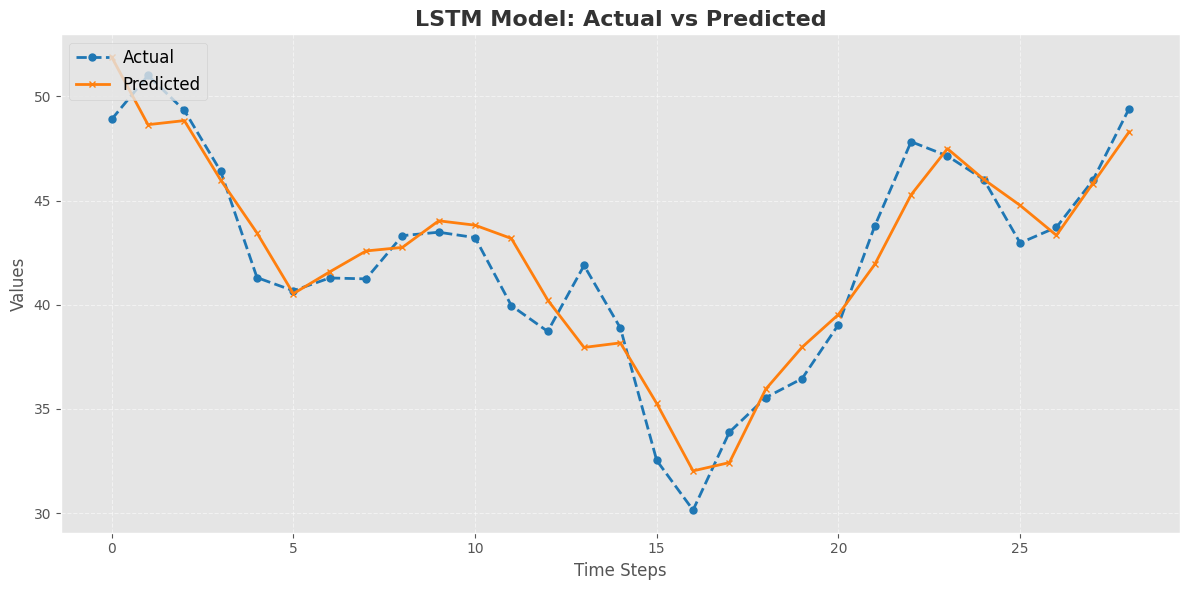

In [ ]:
plt.style.use('ggplot')

# Set figure size and resolution
plt.figure(figsize=(12, 6), dpi=100)

# Plot actual and predicted values
plt.plot(trainY, label="Actual", color="#1f77b4", linewidth=2, linestyle='--', marker='o', markersize=5)
plt.plot(trainPredict, label="Predicted", color="#ff7f0e", linewidth=2, linestyle='-', marker='x', markersize=5)

# Add title, axis labels, and legend
plt.title("LSTM Model: Actual vs Predicted", fontsize=16, fontweight='bold', color='#333333')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.legend(fontsize=12, loc='upper left')

# Customize grid and ticks
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

# **Error Calculation**

In [ ]:
mae = np.mean(np.abs(trainY - trainPredict))
print("Mean Absolute Error (MAE):", mae)

mse = np.mean(np.square(trainY - trainPredict))
print("Mean Squared Error (MSE):", mse)

mape = np.mean(np.abs((trainY - trainPredict) / trainY)) * 100
print("Mean Absolute Percentage Error (MAPE):", mape, "%")

rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

avg_accuracy = 100 - mape
print("Average Accuracy:", avg_accuracy, "%")

Mean Absolute Error (MAE): 1.3075831
Mean Squared Error (MSE): 2.810181
Mean Absolute Percentage Error (MAPE): 3.1947668 %
Root Mean Squared Error (RMSE): 1.6763594
Average Accuracy: 96.80524 %
